# 10b: Dataset EDA — Class Distribution & Scale

Quick exploratory analysis of `foodsg-233_cleaned` (203,655 images, 233 classes) to understand class imbalance and overall dataset scale.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ── Count images per class ──
CLEANED_ROOT = Path("../foodsg-233_cleaned")

class_counts = {}
for class_dir in sorted(CLEANED_ROOT.iterdir()):
    if class_dir.is_dir():
        n = len([f for f in class_dir.iterdir()
                 if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')])
        class_counts[class_dir.name] = n

df = pd.DataFrame({
    'class': list(class_counts.keys()),
    'count': list(class_counts.values())
}).sort_values('count', ascending=False).reset_index(drop=True)

print(f"Classes: {len(df)}")
print(f"Total images: {df['count'].sum():,}")
print(f"\nImages per class:")
print(f"  Mean:   {df['count'].mean():.0f}")
print(f"  Median: {df['count'].median():.0f}")
print(f"  Min:    {df['count'].min()} ({df.iloc[-1]['class']})")
print(f"  Max:    {df['count'].max()} ({df.iloc[0]['class']})")
print(f"  Std:    {df['count'].std():.0f}")
print(f"  Ratio (max/min): {df['count'].max() / df['count'].min():.1f}x")

Classes: 233
Total images: 203,655

Images per class:
  Mean:   874
  Median: 768
  Min:    266 (vegetarian bee hoon)
  Max:    5000 (Chocolate)
  Std:    478
  Ratio (max/min): 18.8x


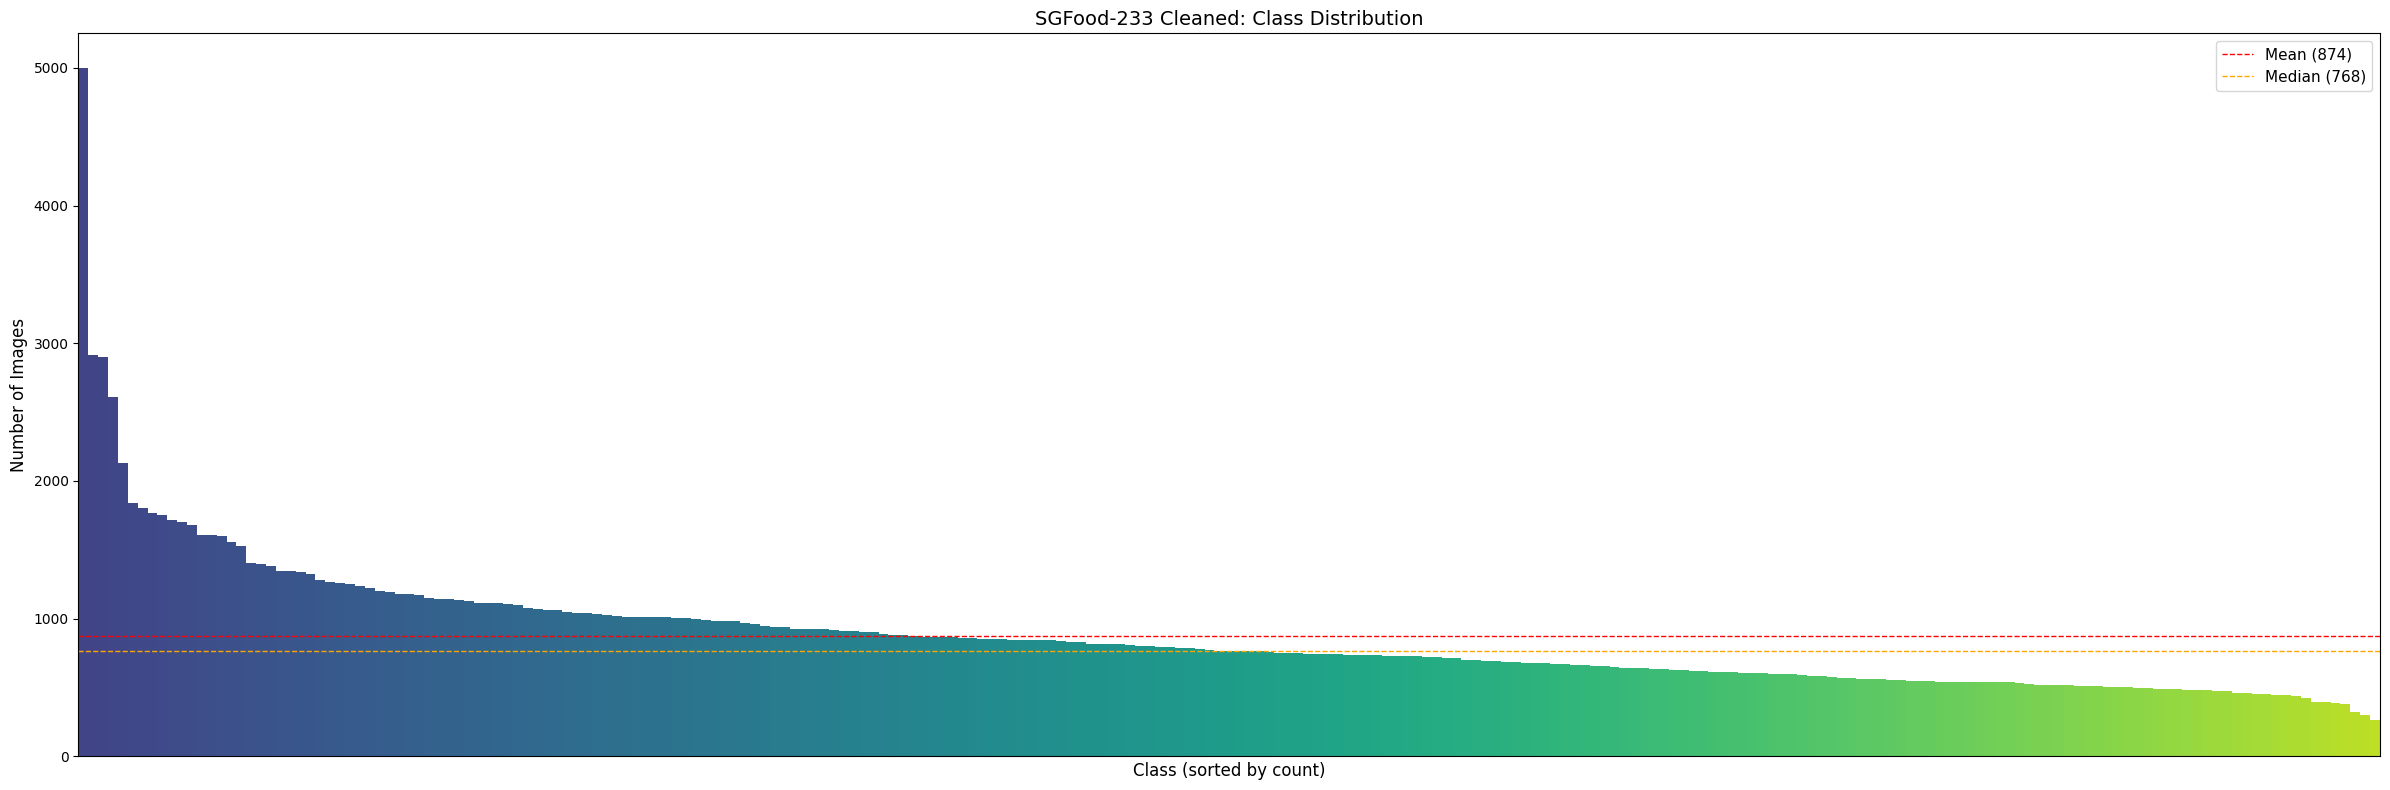

In [3]:
# ── Bar chart: all 233 classes sorted by count ──
fig, ax = plt.subplots(figsize=(24, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df)))
ax.bar(range(len(df)), df['count'].values, color=colors, width=1.0, edgecolor='none')

ax.set_xlabel('Class (sorted by count)', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('SGFood-233 Cleaned: Class Distribution', fontsize=14)
ax.set_xlim(-0.5, len(df) - 0.5)

# Reference lines
mean_val = df['count'].mean()
median_val = df['count'].median()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean ({mean_val:.0f})')
ax.axhline(median_val, color='orange', linestyle='--', linewidth=1, label=f'Median ({median_val:.0f})')
ax.legend(fontsize=11)

ax.set_xticks([])
plt.tight_layout()
plt.show()

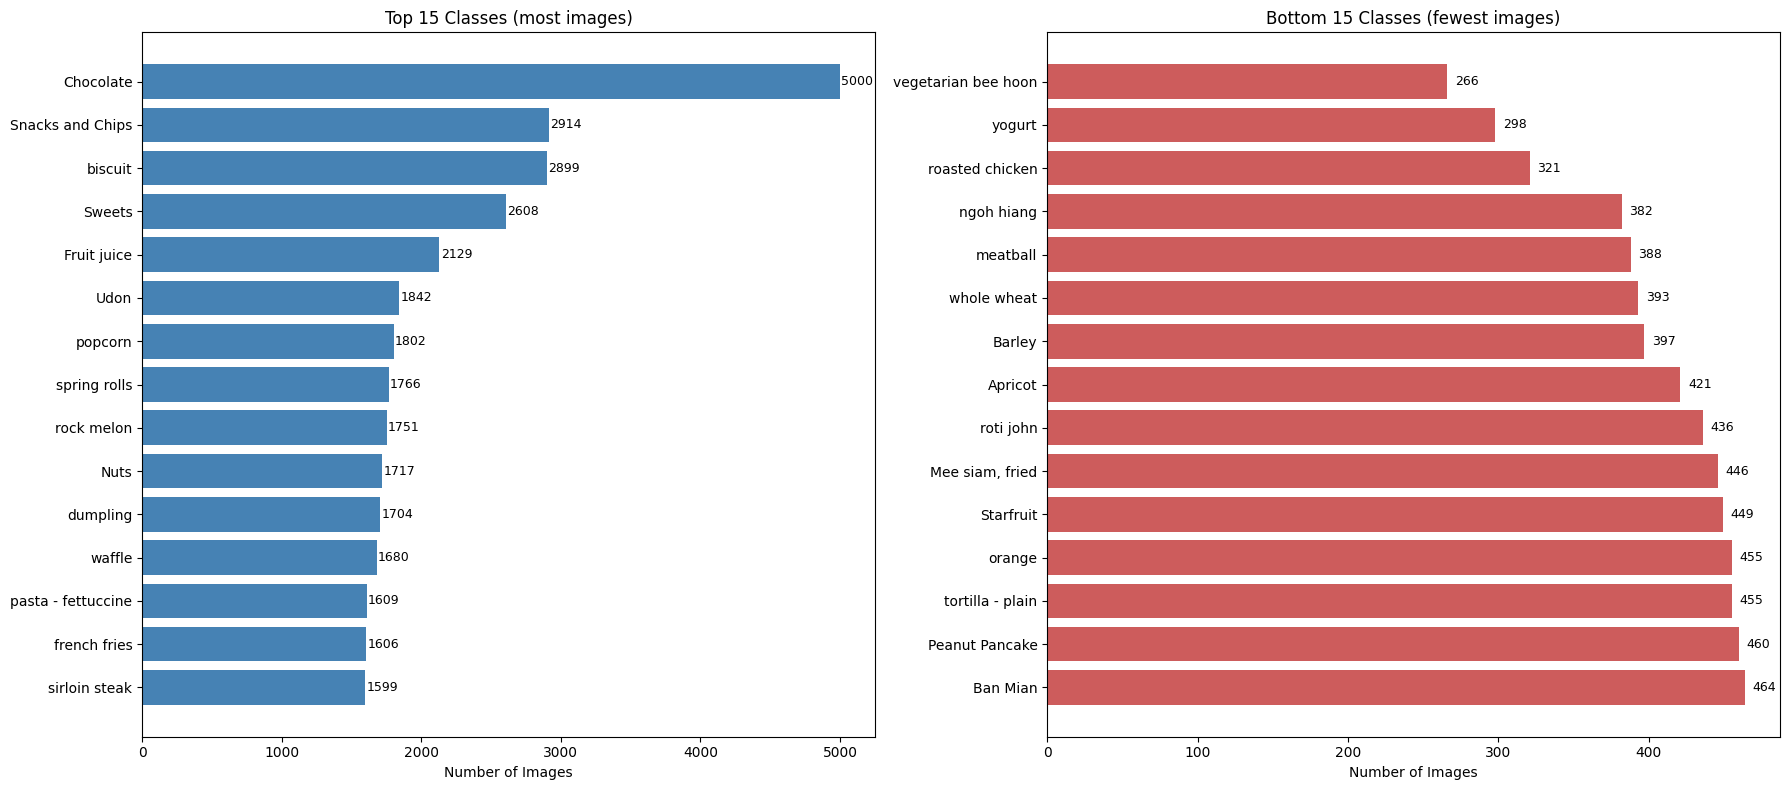

In [4]:
# ── Top 15 and bottom 15 classes ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top = df.head(15)
axes[0].barh(range(len(top)), top['count'].values, color='steelblue')
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels(top['class'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Images')
axes[0].set_title('Top 15 Classes (most images)')
for i, v in enumerate(top['count'].values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

bottom = df.tail(15).iloc[::-1]
axes[1].barh(range(len(bottom)), bottom['count'].values, color='indianred')
axes[1].set_yticks(range(len(bottom)))
axes[1].set_yticklabels(bottom['class'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Images')
axes[1].set_title('Bottom 15 Classes (fewest images)')
for i, v in enumerate(bottom['count'].values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

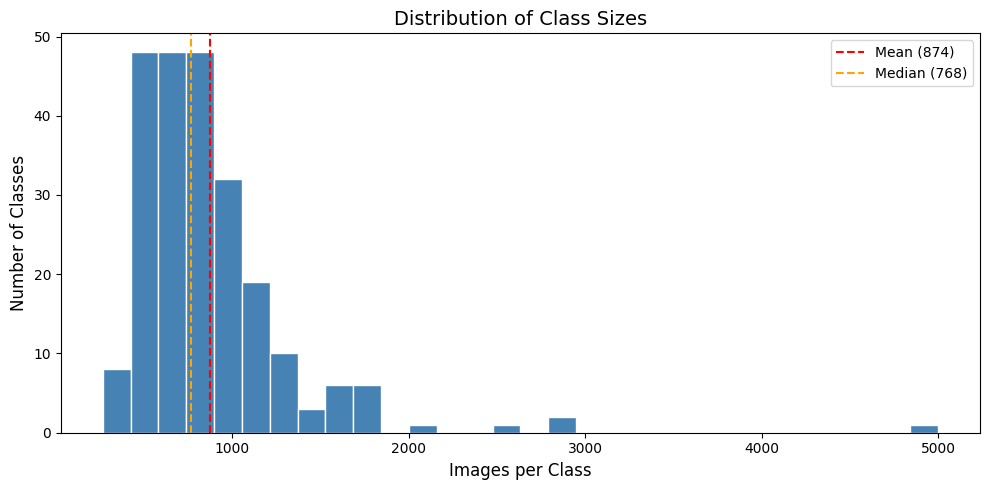

Class size buckets:
  < 500: 24 classes (10.3%)
  < 750: 110 classes (47.2%)
  < 1000: 171 classes (73.4%)


In [5]:
# ── Histogram: distribution of class sizes ──
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['count'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean ({mean_val:.0f})')
ax.axvline(median_val, color='orange', linestyle='--', label=f'Median ({median_val:.0f})')

ax.set_xlabel('Images per Class', fontsize=12)
ax.set_ylabel('Number of Classes', fontsize=12)
ax.set_title('Distribution of Class Sizes', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

# Quick imbalance buckets
thresholds = [500, 750, 1000]
print("Class size buckets:")
for t in thresholds:
    n = (df['count'] < t).sum()
    print(f"  < {t}: {n} classes ({n/len(df)*100:.1f}%)")